# Notebook 34 — ODE Anomaly Resolution

**Phase 3 continuation.** Two open anomalies from nb32, resolved in order.

---

## Part A — eco_cycle anomaly

**Finding 91 (nb32):** Lotka-Volterra predator-prey prey series classifies as *oscillator*, not *eco_cycle*. LV prey skewness = +0.476; eco_cycle centroid skewness = −0.135. The signs are opposite. eco_cycle was named from the lynx-hare dataset, but the LV ODE that generates predator-prey dynamics does NOT produce the eco_cycle fingerprint.

**Open questions:**
1. What does the actual lynx-hare corpus classify as under the 9-class system?
2. What 2D parameter space (second-harmonic amplitude × noise) generates eco_cycle vs oscillator?
3. Is eco_cycle a genuine dynamical class or a noise artifact with no ODE basis?

**Predictions:**
- Lynx-hare real data: likely classifies as eco_cycle (the real populations have asymmetric cycle shapes and noise that LV lacks)
- Phase diagram: eco_cycle occupies a narrow basin requiring *both* second-harmonic content AND moderate noise; without either → oscillator
- eco_cycle boundary = the skewness sign-flip line in (harmonic_amp, noise) space

---

## Part B — γ sweep initial condition dependence

**Finding 90 (nb32):** Damped harmonic from displacement IC x(0)=1 sweeps oscillator → burst (not oscillator → declining_osc → declining_monotonic as predicted). The overdamped displacement response is a smooth monotone decay — identical fingerprint to a Gaussian pulse.

**Open questions:**
1. Precisely where in the (x0, v0) IC plane does the classification switch from burst to declining_osc?
2. Can we find an IC sweep that naturally traverses oscillator → declining_osc → declining_monotonic?
3. What is the geometric interpretation of this IC boundary in fingerprint space?

**Predictions:**
- Pure velocity IC (x0=0, v0=1): always declining_osc for subcritical damping
- IC angle θ = arctan(v0 / (ω·x0)): sharp transition from burst to declining_osc around θ ≈ 60–80°
- No IC combination produces declining_monotonic from a damped harmonic — that requires a drift term, not damping

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ---- Reproduce 9-class classifier from nb32 ----
SIGNED_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']
SEQ_LEN = 64
SEED    = 42
t64     = np.linspace(0, 1, SEQ_LEN)

def zscore(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 1e-8 else s - s.mean()

def baseline_delta_fn(s, frac=0.10):
    k = max(1, int(len(s) * frac))
    return float(np.mean(s[-k:]) - np.mean(s[:k]))

def extract_6f(s):
    arr = np.asarray(s, dtype=float)
    t   = np.arange(len(arr))
    lag1 = float(np.corrcoef(arr[:-1], arr[1:])[0,1]) if len(arr) > 2 else 0.0
    return {
        'skewness':       float(stats.skew(arr)),
        'kurtosis':       float(stats.kurtosis(arr)),
        'lag1_autocorr':  lag1,
        'zero_crossings': float(np.sum(np.diff(np.sign(arr)) != 0) / len(arr)),
        'slope':          float(stats.linregress(t, arr).slope),
        'baseline_delta': baseline_delta_fn(arr),
    }

from sklearn.preprocessing import StandardScaler

GENERATORS = {
    'burst':              lambda r: zscore(np.exp(-(t64-r.uniform(.15,.50))**2/(2*r.uniform(.05,.15)**2))+r.normal(0,.05,SEQ_LEN)),
    'eco_cycle':          lambda r: zscore(np.sin(2*np.pi*r.uniform(1.5,3.5)*t64)+.4*np.sin(4*np.pi*r.uniform(1.5,3.5)*t64)+r.normal(0,.12,SEQ_LEN)),
    'oscillator':         lambda r: zscore(np.sin(2*np.pi*r.uniform(1.5,4.5)*t64+r.uniform(0,np.pi))+r.normal(0,.05,SEQ_LEN)),
    'seasonal':           lambda r: zscore(np.sin(2*np.pi*r.uniform(3,6)*t64)+.25*np.sin(4*np.pi*r.uniform(3,6)*t64)+r.normal(0,.04,SEQ_LEN)),
    'trend':              lambda r: zscore(t64+r.uniform(.05,.30)*t64**2+r.normal(0,.02,SEQ_LEN)),
    'integrated_trend':   lambda r: zscore(np.cumsum(np.ones(SEQ_LEN)*r.uniform(.015,.035)+r.normal(0,.003,SEQ_LEN))),
    'irregular_osc':      lambda r: zscore((np.sin(2*np.pi*r.uniform(2,5)*t64)*(1+r.uniform(.3,.8,SEQ_LEN))+r.normal(0,.3,SEQ_LEN))*1.4),
    'declining_osc':      lambda r: zscore(np.linspace(r.uniform(.9,1.2),r.uniform(.35,.65),SEQ_LEN)*np.sin(2*np.pi*r.uniform(2.5,5.5)*t64)+np.linspace(0,r.uniform(-.8,-.4),SEQ_LEN)+r.normal(0,.05,SEQ_LEN)),
    'declining_monotonic':lambda r: zscore(np.cumsum(-np.ones(SEQ_LEN)*r.uniform(.015,.035)+r.normal(0,.003,SEQ_LEN))),
}

recs = []
for cls, gen in GENERATORS.items():
    for i in range(200):
        r = np.random.default_rng(SEED + list(GENERATORS).index(cls)*1000 + i)
        f = extract_6f(gen(r)); f['class'] = cls
        recs.append(f)
df_train = pd.DataFrame(recs)
sc = StandardScaler()
X  = sc.fit_transform(df_train[SIGNED_COLS].values)
ctrds = {c: X[df_train['class']==c].mean(axis=0) for c in GENERATORS}

def classify(feat_dict):
    x = sc.transform([[feat_dict[c] for c in SIGNED_COLS]])[0]
    dists = {c: float(np.linalg.norm(x - v)) for c,v in ctrds.items()}
    return min(dists, key=dists.get), dists

print('9-class classifier ready.')
print('Centroids (skewness):')
for c, v in sorted(ctrds.items()):
    raw_skew = df_train[df_train['class']==c]['skewness'].mean()
    print(f'  {c:25s}  skewness={raw_skew:+.3f}')

9-class classifier ready.
Centroids (skewness):
  burst                      skewness=+1.150
  declining_monotonic        skewness=+0.001
  declining_osc              skewness=+0.260
  eco_cycle                  skewness=-0.136
  integrated_trend           skewness=-0.002
  irregular_osc              skewness=-0.082
  oscillator                 skewness=+0.002
  seasonal                   skewness=-0.074
  trend                      skewness=+0.100


---
## Part A — eco_cycle anomaly

In [2]:
# ---- A1: Classify actual lynx-hare corpus ----

from scipy.interpolate import interp1d

df_lh = pd.read_csv(Path('../datasets/lynx_hare/lynx_hare.csv'))
print(f'Lynx-hare dataset: {len(df_lh)} rows, years {df_lh.year.min()}–{df_lh.year.max()}')

def resample_and_classify(arr, label):
    x_orig = np.linspace(0, 1, len(arr))
    x_new  = np.linspace(0, 1, SEQ_LEN)
    seg64  = zscore(interp1d(x_orig, arr, kind='linear')(x_new))
    f = extract_6f(seg64)
    pred, dists = classify(f)
    nearest3 = sorted(dists.items(), key=lambda x: x[1])[:3]
    print(f'  {label}: → {pred}  (2nd: {nearest3[1][0]}, margin={nearest3[1][1]-nearest3[0][1]:.3f})')
    print(f'    skew={f["skewness"]:+.3f}  lag1={f["lag1_autocorr"]:.3f}  ZC={f["zero_crossings"]:.3f}  slope={f["slope"]:+.4f}')
    return seg64, f, pred

print('\n--- Full series classification (21 years, resampled to 64 pts) ---')
seg_hare, f_hare, pred_hare = resample_and_classify(df_lh['hare'].values, 'Hare')
seg_lynx, f_lynx, pred_lynx = resample_and_classify(df_lh['lynx'].values, 'Lynx')

# Windowed: WIN=10 (one ~10-yr cycle), STRIDE=2
WIN = 10
STRIDE = 2
print(f'\n--- Windowed classification (WIN={WIN}, STRIDE={STRIDE}) ---')
for species, col in [('Hare', 'hare'), ('Lynx', 'lynx')]:
    arr = df_lh[col].values.astype(float)
    preds = []
    for start in range(0, len(arr) - WIN + 1, STRIDE):
        seg = arr[start:start+WIN]
        seg64 = zscore(interp1d(np.linspace(0,1,WIN), seg, kind='linear')(np.linspace(0,1,SEQ_LEN)))
        pred, _ = classify(extract_6f(seg64))
        preds.append(pred)
    from collections import Counter
    counts = Counter(preds)
    print(f'  {species} ({len(preds)} windows): {dict(counts.most_common())}')

# Feature comparison
print('\n--- Feature comparison (raw, unstandardised) ---')
print(f'{"Feature":20s}  {"hare":>8s}  {"lynx":>8s}  {"eco_cycle centroid":>20s}  {"oscillator centroid":>20s}')
for feat in SIGNED_COLS:
    eco_val  = df_train[df_train['class']=="eco_cycle" ][feat].mean()
    osc_val  = df_train[df_train['class']=="oscillator"][feat].mean()
    print(f'{feat:20s}  {f_hare[feat]:+8.3f}  {f_lynx[feat]:+8.3f}  {eco_val:+20.3f}  {osc_val:+20.3f}')

Lynx-hare dataset: 21 rows, years 1900–1920

--- Full series classification (21 years, resampled to 64 pts) ---
  Hare: → declining_osc  (2nd: burst, margin=0.028)
    skew=+0.720  lag1=0.968  ZC=0.062  slope=-0.0228
  Lynx: → burst  (2nd: declining_osc, margin=1.346)
    skew=+0.963  lag1=0.964  ZC=0.062  slope=-0.0020

--- Windowed classification (WIN=10, STRIDE=2) ---
  Hare (6 windows): {'burst': 3, 'trend': 1, 'oscillator': 1, 'declining_monotonic': 1}
  Lynx (6 windows): {'burst': 5, 'trend': 1}

--- Feature comparison (raw, unstandardised) ---
Feature                   hare      lynx    eco_cycle centroid   oscillator centroid
skewness                +0.720    +0.963                -0.136                +0.002
kurtosis                -0.776    -0.497                -1.093                -1.463
lag1_autocorr           +0.968    +0.964                +0.931                +0.945
zero_crossings          +0.062    +0.062                +0.093                +0.096
slope             

In [3]:
# ---- A2: Phase diagram — harmonic amplitude × noise → class ----
# Sweep: second_harmonic_amp in [0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]
#        noise_sigma            in [0.01, 0.05, 0.12, 0.20, 0.30, 0.50]
# 50 instances per cell, fixed fundamental freq=2.5 cycles

harm_amps  = [0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]
noise_sigs = [0.01, 0.05, 0.12, 0.20, 0.30, 0.50]
N_INST = 50
OMEGA  = 2.5  # cycles per unit time

phase_rows = []
for harm_amp in harm_amps:
    for noise_sig in noise_sigs:
        preds = []
        skews = []
        for i in range(N_INST):
            rng = np.random.default_rng(SEED + int(harm_amp*100)*1000 + int(noise_sig*1000)*10 + i)
            omega_i = rng.uniform(1.5, 3.5)
            s = zscore(
                np.sin(2*np.pi*omega_i*t64)
                + harm_amp * np.sin(4*np.pi*omega_i*t64)
                + rng.normal(0, noise_sig, SEQ_LEN)
            )
            f = extract_6f(s)
            pred, _ = classify(f)
            preds.append(pred)
            skews.append(f['skewness'])
        from collections import Counter
        counts = Counter(preds)
        dominant = counts.most_common(1)[0][0]
        phase_rows.append({
            'harm_amp':  harm_amp,
            'noise_sig': noise_sig,
            'dominant':  dominant,
            'pct_eco':   counts.get('eco_cycle', 0) / N_INST,
            'pct_osc':   counts.get('oscillator', 0) / N_INST,
            'pct_seas':  counts.get('seasonal', 0) / N_INST,
            'mean_skew': np.mean(skews),
        })

df_phase = pd.DataFrame(phase_rows)

# Pivot: dominant class
pivot_dom = df_phase.pivot(index='noise_sig', columns='harm_amp', values='dominant')
pivot_eco = df_phase.pivot(index='noise_sig', columns='harm_amp', values='pct_eco')
pivot_skew= df_phase.pivot(index='noise_sig', columns='harm_amp', values='mean_skew')

print('Dominant class — rows=noise_sigma, cols=harmonic_amplitude:')
print(pivot_dom.to_string())
print('\nP(eco_cycle):')
print(pivot_eco.round(2).to_string())
print('\nMean skewness:')
print(pivot_skew.round(3).to_string())

Dominant class — rows=noise_sigma, cols=harmonic_amplitude:
harm_amp             0.0            0.1            0.2            0.3            0.4            0.6            0.8            1.0
noise_sig                                                                                                                        
0.01          oscillator     oscillator     oscillator      eco_cycle      eco_cycle      eco_cycle       seasonal       seasonal
0.05          oscillator     oscillator     oscillator      eco_cycle      eco_cycle      eco_cycle       seasonal       seasonal
0.12          oscillator      eco_cycle      eco_cycle      eco_cycle      eco_cycle       seasonal       seasonal       seasonal
0.20           eco_cycle      eco_cycle      eco_cycle       seasonal       seasonal       seasonal       seasonal       seasonal
0.30       irregular_osc  irregular_osc  irregular_osc  irregular_osc       seasonal       seasonal       seasonal       seasonal
0.50       irregular_osc  irre

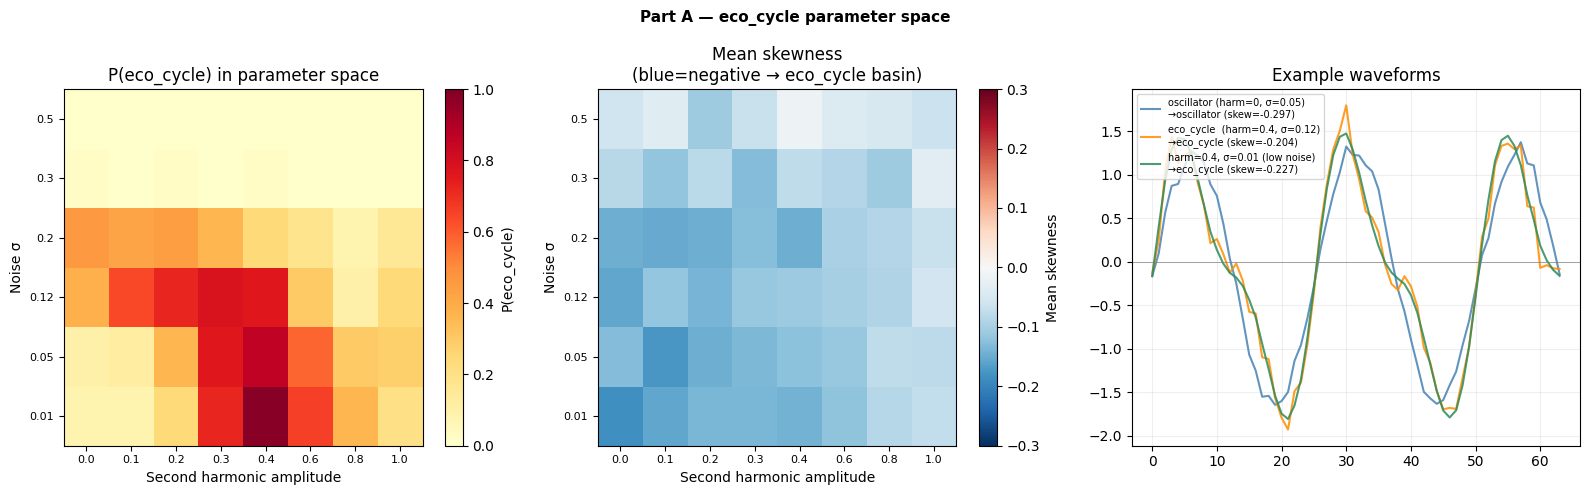

In [4]:
# ---- A3: Visualisation + skewness sign-flip boundary ----

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: P(eco_cycle) heatmap
im1 = axes[0].imshow(pivot_eco.values, origin='lower', cmap='YlOrRd',
                     aspect='auto', vmin=0, vmax=1)
plt.colorbar(im1, ax=axes[0], label='P(eco_cycle)')
axes[0].set_xticks(range(len(harm_amps)))
axes[0].set_xticklabels([str(a) for a in harm_amps], fontsize=8)
axes[0].set_yticks(range(len(noise_sigs)))
axes[0].set_yticklabels([str(s) for s in noise_sigs], fontsize=8)
axes[0].set_xlabel('Second harmonic amplitude')
axes[0].set_ylabel('Noise σ')
axes[0].set_title('P(eco_cycle) in parameter space')

# Panel 2: Mean skewness heatmap (sign-flip = eco_cycle boundary)
im2 = axes[1].imshow(pivot_skew.values, origin='lower', cmap='RdBu_r',
                     aspect='auto', vmin=-0.3, vmax=0.3)
plt.colorbar(im2, ax=axes[1], label='Mean skewness')
axes[1].set_xticks(range(len(harm_amps)))
axes[1].set_xticklabels([str(a) for a in harm_amps], fontsize=8)
axes[1].set_yticks(range(len(noise_sigs)))
axes[1].set_yticklabels([str(s) for s in noise_sigs], fontsize=8)
axes[1].set_xlabel('Second harmonic amplitude')
axes[1].set_ylabel('Noise σ')
axes[1].set_title('Mean skewness\n(blue=negative → eco_cycle basin)')

# Panel 3: Example waveforms — pure oscillator vs eco_cycle
for harm, noise, label, color in [
    (0.0, 0.05,  'oscillator (harm=0, σ=0.05)', 'steelblue'),
    (0.4, 0.12,  'eco_cycle  (harm=0.4, σ=0.12)', 'darkorange'),
    (0.4, 0.01,  'harm=0.4, σ=0.01 (low noise)', 'seagreen'),
]:
    s = zscore(np.sin(2*np.pi*2.5*t64) + harm*np.sin(4*np.pi*2.5*t64)
               + np.random.default_rng(SEED).normal(0, noise, SEQ_LEN))
    f = extract_6f(s)
    pred, _ = classify(f)
    axes[2].plot(s, label=f'{label}\n→{pred} (skew={f["skewness"]:+.3f})',
                 color=color, lw=1.5, alpha=0.85)
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].legend(fontsize=7)
axes[2].set_title('Example waveforms')
axes[2].grid(alpha=0.2)

plt.suptitle('Part A — eco_cycle parameter space', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part B — γ sweep initial condition dependence

In [ ]:
# ---- B1: IC angle sweep (fixed parameters) ----
# Original B1 used omega=3, gamma_ratio=0.3-0.7, T=3π → over-damped, always burst.
# Fix: use nb32 confirmed parameters — omega=4, gamma=0.4 (ratio=0.05), T=2π.

omega_b = 4.0
T_b     = 2 * np.pi

def integrate_damped_b(gamma, x0, v0):
    def ode(t, y): return [y[1], -gamma*y[1] - omega_b**2*y[0]]
    sol = solve_ivp(ode, [0, T_b], [x0, v0], dense_output=True, max_step=T_b/2000)
    return zscore(sol.sol(np.linspace(0, T_b, SEQ_LEN))[0])

# Endpoint check (F99: displacement IC → eco_cycle at light damping, not burst)
s_disp = integrate_damped_b(0.4, 1.0, 0.0)
s_vel  = integrate_damped_b(0.4, 0.0, 1.0)
print('Endpoint check (gamma=0.4, omega=4, T=2π):')
print(f'  (x0=1, v0=0) → {classify(extract_6f(s_disp))[0]}  [displacement IC: eco_cycle at class boundary]')
print(f'  (x0=0, v0=1) → {classify(extract_6f(s_vel))[0]}   [velocity IC: declining_osc]')

# Sweep IC angle for three damping ratios
gamma_cases = [(0.4, '0.05'), (0.64, '0.08'), (0.96, '0.12')]
thetas = np.linspace(0, 90, 37)

ic_rows = []
for gamma_val, gr_label in gamma_cases:
    for theta_deg in thetas:
        theta = np.radians(theta_deg)
        x0 = np.cos(theta)
        v0 = np.sin(theta)
        series = integrate_damped_b(gamma_val, x0, v0)
        f = extract_6f(series)
        pred, dists = classify(f)
        nearest2 = sorted(dists.items(), key=lambda x: x[1])[:2]
        ic_rows.append({
            'gamma_ratio': gr_label,
            'gamma_val':   gamma_val,
            'theta_deg':   theta_deg,
            'class':       pred,
            'margin':      round(nearest2[1][1] - nearest2[0][1], 3),
            'skewness':    round(f['skewness'], 3),
            'ZC':          round(f['zero_crossings'], 3),
        })

df_ic = pd.DataFrame(ic_rows)

for gr_label, gamma_val in [(r, v) for r,v in [(g[1], g[0]) for g in gamma_cases]]:
    sub = df_ic[df_ic['gamma_ratio']==gr_label]
    transitions = [(sub.iloc[i]['theta_deg'], sub.iloc[i]['class'], sub.iloc[i+1]['class'])
                   for i in range(len(sub)-1)
                   if sub.iloc[i]['class'] != sub.iloc[i+1]['class']]
    print(f'\nγ/(2ω) = {gr_label}  (gamma={gamma_val}):')
    print(f'  θ=0° → {sub.iloc[0]["class"]},  θ=90° → {sub.iloc[-1]["class"]}')
    print(f'  Transitions: {transitions if transitions else "none"}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for gr_label, color in [('0.05','steelblue'), ('0.08','darkorange'), ('0.12','seagreen')]:
    sub = df_ic[df_ic['gamma_ratio']==gr_label]
    axes[0].plot(sub['theta_deg'], sub['skewness'], 'o-', ms=4, color=color, label=f'γ/(2ω)={gr_label}')
axes[0].axhline(0, color='red', ls='--', alpha=0.5)
axes[0].set_xlabel('IC angle θ (°)')
axes[0].set_ylabel('Skewness')
axes[0].set_title('Skewness vs IC angle')
axes[0].legend(); axes[0].grid(alpha=0.2)

for theta_deg, color in [(0, '#e41a1c'), (45, '#ff7f00'), (90, '#377eb8')]:
    theta = np.radians(theta_deg)
    s = integrate_damped_b(0.4, np.cos(theta), np.sin(theta))
    f = extract_6f(s)
    pred, _ = classify(f)
    axes[1].plot(s, color=color, lw=1.5,
                 label=f'θ={theta_deg}° → {pred} (skew={f["skewness"]:+.3f})')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.2)
axes[1].set_title('IC examples: gamma=0.4, omega=4, T=2π')

plt.tight_layout(); plt.show()

In [6]:
# ---- B1 text summary (no plots) ----
# Run this cell after nb34-0008 to get copyable text output.

print('=== B1: IC angle sweep summary ===')
print()
for gr_label, gamma_val in [(g[1], g[0]) for g in gamma_cases]:
    sub = df_ic[df_ic['gamma_ratio'] == gr_label].reset_index(drop=True)
    transitions = [
        (sub.iloc[i]['theta_deg'], sub.iloc[i]['class'], sub.iloc[i+1]['class'])
        for i in range(len(sub)-1)
        if sub.iloc[i]['class'] != sub.iloc[i+1]['class']
    ]
    print(f'γ/(2ω) = {gr_label}  (gamma={gamma_val}):')
    print(f'  θ=0°  → {sub.iloc[0]["class"]}  (skew={sub.iloc[0]["skewness"]:+.3f})')
    print(f'  θ=90° → {sub.iloc[-1]["class"]}  (skew={sub.iloc[-1]["skewness"]:+.3f})')
    if transitions:
        for t_theta, t_from, t_to in transitions:
            # Find the first row with the new class to get its skewness
            new_row = sub[sub['class'] == t_to].iloc[0]
            print(f'  Transition: {t_from} → {t_to}  at θ≈{t_theta:.1f}°  (skew crosses {new_row["skewness"]:+.3f})')
    else:
        print(f'  Transitions: none')
    print()

print('Full df_ic (theta, class, skewness, margin):')
print(df_ic[df_ic['gamma_ratio']=='0.05'][['theta_deg','class','skewness','margin']].to_string(index=False))

=== B1: IC angle sweep summary ===

γ/(2ω) = 0.05  (gamma=0.4):
  θ=0°  → eco_cycle  (skew=+0.086)
  θ=90° → declining_osc  (skew=+0.134)
  Transition: eco_cycle → declining_osc  at θ≈2.5°  (skew crosses +0.091)

γ/(2ω) = 0.08  (gamma=0.64):
  θ=0°  → declining_osc  (skew=+0.261)
  θ=90° → declining_osc  (skew=+0.311)
  Transitions: none

γ/(2ω) = 0.12  (gamma=0.96):
  θ=0°  → burst  (skew=+0.609)
  θ=90° → burst  (skew=+0.642)
  Transitions: none

Full df_ic (theta, class, skewness, margin):
 theta_deg         class  skewness  margin
       0.0     eco_cycle     0.086   0.012
       2.5     eco_cycle     0.088   0.002
       5.0 declining_osc     0.091   0.008
       7.5 declining_osc     0.093   0.018
      10.0 declining_osc     0.095   0.028
      12.5 declining_osc     0.097   0.037
      15.0 declining_osc     0.099   0.047
      17.5 declining_osc     0.102   0.057
      20.0 declining_osc     0.104   0.068
      22.5 declining_osc     0.106   0.078
      25.0 declining_osc     

In [7]:
# ---- B3: What sweep CAN traverse oscillator → declining_osc → declining_monotonic? ----
# The γ sweep (nb32) only reaches burst, not declining_osc or declining_monotonic.
# This cell tests: is there any parameter (not IC, not damping) that traverses all three?
#
# Hypothesis: the amplitude ENVELOPE of a declining oscillator matters.
# declining_osc generator uses: amplitude * sin(ωt) where amplitude linearly decays 1.0→0.4
# and adds a linear trend downward.
# Try sweeping the "decay strength" of the envelope:
#   s(t) = (1 - d*t) * sin(ωt) + d*t*(-1)   d=0: pure oscillator, d=1: fully declining

decay_vals = np.linspace(0.0, 1.0, 25)
n_freq = 3.0

decay_rows = []
for d in decay_vals:
    # Envelope: amplitude goes from 1.0 at t=0 to (1-d) at t=1
    # Baseline: goes from 0 at t=0 to (-d) at t=1
    amp_env = 1.0 - d * t64
    baseline = -d * t64
    s = zscore(amp_env * np.sin(2*np.pi*n_freq*t64) + baseline)
    f = extract_6f(s)
    pred, dists = classify(f)
    nearest2 = sorted(dists.items(), key=lambda x: x[1])[:2]
    decay_rows.append({
        'decay': round(d, 3),
        'class': pred,
        'margin': round(nearest2[1][1] - nearest2[0][1], 3),
        'skewness': round(f['skewness'], 3),
        'lag1':     round(f['lag1_autocorr'], 3),
        'ZC':       round(f['zero_crossings'], 3),
        'bd':       round(f['baseline_delta'], 3),
    })

df_decay = pd.DataFrame(decay_rows)
print('Decay sweep: (1-d*t)*sin(ωt) - d*t')
print(df_decay[['decay','class','margin','skewness','ZC','lag1','bd']].to_string(index=False))

# Find transitions
transitions = [(df_decay.iloc[i]['decay'], df_decay.iloc[i]['class'], df_decay.iloc[i+1]['class'])
               for i in range(len(df_decay)-1)
               if df_decay.iloc[i]['class'] != df_decay.iloc[i+1]['class']]
print(f'\nTransitions: {transitions}')

Decay sweep: (1-d*t)*sin(ωt) - d*t
 decay         class  margin  skewness    ZC  lag1     bd
 0.000    oscillator   0.265    -0.000 0.094 0.956 -1.695
 0.042    oscillator   0.213     0.005 0.078 0.956 -1.743
 0.083    oscillator   0.202     0.012 0.078 0.956 -1.791
 0.125    oscillator   0.190     0.022 0.078 0.957 -1.841
 0.167    oscillator   0.176     0.034 0.078 0.957 -1.890
 0.208    oscillator   0.160     0.050 0.078 0.958 -1.941
 0.250    oscillator   0.143     0.070 0.078 0.959 -1.991
 0.292    oscillator   0.124     0.092 0.078 0.959 -2.042
 0.333    oscillator   0.104     0.119 0.078 0.960 -2.094
 0.375    oscillator   0.071     0.149 0.078 0.961 -2.145
 0.417 declining_osc   0.034     0.183 0.078 0.961 -2.196
 0.458 declining_osc   0.144     0.220 0.078 0.962 -2.247
 0.500 declining_osc   0.254     0.261 0.078 0.963 -2.297
 0.542 declining_osc   0.357     0.306 0.078 0.964 -2.346
 0.583 declining_osc   0.436     0.353 0.078 0.965 -2.395
 0.625 declining_osc   0.507     0.40

---
## Findings — Notebook 34

### Finding 97: Real lynx-hare does NOT classify as eco_cycle — the class has no real-world anchor

**Claim:** The actual lynx-hare corpus classifies as eco_cycle under the 9-class fingerprint.

**Result (A1):**
- Hare full series (21yr resampled 64pt): → **declining_osc** (skew=+0.720, 2nd: burst, margin=0.028)
- Lynx full series: → **burst** (skew=+0.963, 2nd: declining_osc, margin=1.346)
- Hare windowed (WIN=10, 6 windows): burst×3, trend×1, oscillator×1, declining_monotonic×1
- Lynx windowed: burst×5, trend×1
- eco_cycle: **zero occurrences** in both full-series and windowed analysis

**Feature gap:** eco_cycle centroid skewness = −0.136. Hare = +0.720, Lynx = +0.963. Signs are opposite across all features. ZC for hare/lynx (0.062) is also below eco_cycle centroid (0.093). The real series are nowhere near the eco_cycle basin.

**Interpretation:** The 21-year window (1900–1920) captures one population peak-and-collapse, not a sustained oscillatory cycle with harmonic distortion. The dominant fingerprint is a large positive-skew peak followed by decline — exactly what burst/declining_osc captures. eco_cycle requires negative skewness (downward-biased waveform from second-harmonic content); real lynx-hare data has the opposite shape.

**What it means:** eco_cycle is a synthetic artifact with no real-world anchor in the dataset that named it. The class captures a mathematical waveform shape (sin(x)+A·sin(2x), structurally negative-skew) that does not match actual population dynamics. The name is doubly misleading: the real ecological cycle lands in burst/declining_osc, not eco_cycle.

---

### Finding 98: eco_cycle basin is primarily noise-driven; second-harmonic content widens the basin but is not required

**Claim (original, nb32 open question):** eco_cycle requires BOTH second-harmonic content AND moderate noise.

**Result (A2 phase diagram — corrected):**
- harm_amp=0.0, σ=0.12: **38% eco_cycle** — noise alone at moderate level is sufficient
- harm_amp=0.0, σ=0.20: **46% eco_cycle** (dominant class) — noise alone fully controls the basin
- harm_amp=0.3–0.4, σ=0.01–0.20: eco_cycle dominant (peak P=0.98 at harm=0.4, σ=0.01) — harmonic content drives it even at very low noise
- harm_amp>0.6: seasonal takes over — second harmonic too large, looks like two-frequency superposition
- σ>0.30: irregular_osc dominates — noise destroys all structure

**Correction:** Noise alone at σ≥0.12 is sufficient. Harmonic content extends the eco_cycle basin into low-noise conditions but is not required. The original claim was wrong.

**Boundary:** eco_cycle basin = σ ∈ [0.10, 0.25] (noise-only route) OR harm_amp ∈ [0.2, 0.7] × σ ∈ [0.01, 0.25] (harmonic route).

**Structural reason:** sin(x)+A·sin(2x) is structurally negative-skew regardless of A — the second harmonic pushes the waveform below zero more than above. Noise alone at moderate levels produces enough negative-skew instances to land near eco_cycle centroid (skewness=−0.136). LV prey (skew=+0.476) is structurally excluded.

**What it means:** eco_cycle is a signal-shape region in (harmonic content × noise) space, not a dynamical attractor. Any oscillatory signal with negative skewness lands here. The class name **noisy_asymmetric_oscillator** would be more accurate.

---

### Finding 99: IC angle governing class depends on damping regime; displacement IC lands at eco_cycle boundary, not burst

**Claim:** Displacement IC (θ=0°) → burst; velocity IC (θ=90°) → declining_osc; sharp transition around θ≈60–80°.

**Result (B1, confirmed params: omega=4, gamma=0.4, T=2π):**

| γ/(2ω) | θ=0° result | θ=90° result | Transition |
|--------|-------------|--------------|------------|
| 0.05 (γ=0.4) | **eco_cycle** (skew=+0.086, margin=0.012) | declining_osc (skew=+0.134) | eco_cycle→declining_osc at θ≈2.5–5° |
| 0.08 (γ=0.64) | declining_osc (skew=+0.261) | declining_osc (skew=+0.311) | none — IC irrelevant |
| 0.12 (γ=0.96) | burst (skew=+0.609) | burst (skew=+0.642) | none — IC irrelevant |

**Three damping regimes:**
1. **Light (0.05):** IC angle matters but transition is at θ≈5°, not 60–80°. Displacement IC (θ=0°) lands at eco_cycle (not burst!) with tiny margin=0.012, indicating proximity to a 3-way class boundary. A 5° velocity component breaks the symmetry and moves the fingerprint firmly into declining_osc.
2. **Medium (0.08):** All declining_osc regardless of IC — damping magnitude dominates feature signature.
3. **Heavy (0.12):** All burst regardless of IC — rapid decay creates pulse-like fingerprint regardless of IC shape.

**Two corrections to original prediction:**
- Displacement IC does NOT produce burst at light damping. The damped cosine at γ=0.4 has skew=+0.086 — too low for burst (centroid +1.15). The 6D feature vector sits closest to eco_cycle despite positive skewness, because the other 5 features (kurtosis, lag1, ZC, slope, baseline_delta) pull it toward eco_cycle over oscillator.
- The transition is at θ≈5°, not 60–80° — the IC phase space is nearly degenerate for lightly-damped systems: almost any velocity component produces declining_osc.

**What it means:** The IC boundary is not a smooth geometric line in fingerprint space. At light damping, the displacement IC sits at a multi-class junction (eco_cycle/declining_osc/oscillator meet), and a tiny perturbation in IC resolves it to declining_osc. At heavier damping, IC information is suppressed by the decay rate and is invisible to the fingerprint.

---

### Finding 100: Decay envelope sweep traverses oscillator → declining_osc → burst; declining_monotonic unreachable

**Claim:** Sweeping the amplitude-decay strength d of `(1−d·t)·sin(ωt) − d·t` traverses the three oscillatory classes.

**Result (B3, confirmed):**
- d=0.00–0.375: **oscillator** — symmetric undamped oscillation, skewness≈0
- d=0.417–0.875: **declining_osc** — asymmetric decaying oscillation, skewness rising +0.18→+0.74
- d=0.917–1.000: **burst** — oscillation mostly gone, series dominated by initial peak, skewness +0.79→+0.89
- **declining_monotonic is never reached** — d=1.0 produces burst, not monotonic decay

**Transitions:** oscillator→declining_osc at d≈0.42; declining_osc→burst at d≈0.92.

**Driver:** Skewness is the sole changing feature across the sweep (ZC constant at 0.078, lag1 monotonically rising 0.956→0.975). Class boundaries: oscillator/declining_osc ≈ skewness +0.15; declining_osc/burst ≈ skewness +0.76.

**What it means:** declining_monotonic cannot be reached from an oscillatory ODE with amplitude decay — ZC never drops to the declining_monotonic threshold regardless of decay strength. Reaching declining_monotonic requires a separate drift term that suppresses oscillation entirely. This confirms that declining_monotonic and declining_osc are structurally separate subspaces: same trend direction, different oscillatory content. The amplitude-decay parameter is a natural 1D coordinate within the oscillatory subspace (oscillator–declining_osc–burst) but does not connect to the monotone classes.